In [1]:
#Import necessary libraries


import pandas as pd # data manipulation
import numpy as np # numerical operations
import seaborn as sns # data visualization
import matplotlib.pyplot as plt # plotting
from sklearn.preprocessing import StandardScaler # feature scaling
from sklearn.model_selection import train_test_split # data splitting
from sklearn.impute import SimpleImputer # handling missing values
import statsmodels.api as sm # for statistical modeling
from sklearn.feature_selection import RFE # Recursive Feature Elimination for feature selection
from sklearn.linear_model import LogisticRegression # Logistic Regression model for RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor # VIF calculation for multicollinearity check
import warnings # to ignore warnings
warnings.filterwarnings('ignore')  # Ignore warnings for cleaner output

In [2]:
#load the dataset

Lead_df=pd.read_csv("Leads.csv")

In [3]:
# show the first few rows of the dataset to understand its structure and contents

Lead_df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [4]:
# Select all columns with object data type (text columns) from the DataFrame
text_columns = Lead_df.select_dtypes(include=['object']).columns

# apply the str.strip() method to each text column to remove leading and trailing whitespace
for col in text_columns:
    Lead_df[col] = Lead_df[col].str.strip()

In [5]:
#replace empty strings with NaN values for better handling of missing data

Lead_df.drop(['Prospect ID'], axis=1, inplace=True, errors='ignore')

In [6]:
# show the first few rows of the dataset to understand its structure and contents

Lead_df.head()

,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [7]:
import numpy as np

# Poore dataset mein jahan bhi 'Select' likha hai, use NaN (Not a Number) bana dein
Lead_df = Lead_df.replace('Select', np.nan)

# Ab check karein ki har column mein kitne % missing values ho gaye hain
missing_percentage = round(100*(Lead_df.isnull().sum()/len(Lead_df.index)), 2)
print("Missing Values Percentage:\n", missing_percentage[missing_percentage > 0].sort_values(ascending=False))

Missing Values Percentage:
 How did you hear about X Education               78.46
Lead Profile                                     74.19
Lead Quality                                     51.59
Asymmetrique Activity Index                      45.65
Asymmetrique Profile Index                       45.65
Asymmetrique Profile Score                       45.65
Asymmetrique Activity Score                      45.65
City                                             39.71
Specialization                                   36.58
Tags                                             36.29
What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
Page Views Per Visit                              1.48
TotalVisits                                       1.48
Last Activity                                     1.11
Lead Source                                       0.39
dtype: float64


In [8]:
# Get information about the dataset

Lead_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 36 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Lead Number                                    9240 non-null   int64  
 1   Lead Origin                                    9240 non-null   str    
 2   Lead Source                                    9204 non-null   str    
 3   Do Not Email                                   9240 non-null   str    
 4   Do Not Call                                    9240 non-null   str    
 5   Converted                                      9240 non-null   int64  
 6   TotalVisits                                    9103 non-null   float64
 7   Total Time Spent on Website                    9240 non-null   int64  
 8   Page Views Per Visit                           9103 non-null   float64
 9   Last Activity                                  9137 non-null   

In [9]:
# Check for duplicate rows in the dataset and count them

Lead_df.duplicated().sum()

np.int64(0)

In [10]:
# Check for missing values in the dataset and count them
Lead_df.isnull().sum()

Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   3380
How did you hear about X Education               7250
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article                                   0
X Education Forums          

In [11]:
# drop the columns 'Lead Quality' and 'Asymmetrique Profile Score' from the DataFrame

Lead_df = Lead_df.drop(['Lead Quality', 'How did you hear about X Education?', 'Asymmetrique Profile Score', 'Asymmetrique Activity Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Index'], axis=1, errors='ignore')

In [12]:
#fill missing values in specific columns with 'Not Specified'

cols_to_fill = [
    'Tags', 
    'What matters most to you in choosing a course', 
    'What is your current occupation', 
    'Country', 
    'City',
    'How did you hear about X Education', 
    'Specialization'
]

# iterate over the specified columns and fill missing values with 'Not Specified'
for col in cols_to_fill:
    for col in cols_to_fill:
        if col in Lead_df.columns:
            Lead_df[col] = Lead_df[col].fillna('Not Specified')
        else:
            # create the column if missing so later steps (e.g. get_dummies) don't fail
            Lead_df[col] = 'Not Specified'

In [13]:
#drop rows where any of the specified columns have unknown missing values 
cols = ['TotalVisits', 'Page Views Per Visit', 'Last Activity', 'Lead Source']
existing = [c for c in cols if c in Lead_df.columns]
if existing:
    Lead_df = Lead_df.dropna(subset=existing)

In [14]:
#checking the number of missing values in each column after handling missing values
Lead_df.isnull().sum()

Lead Number                                         0
Lead Origin                                         0
Lead Source                                         0
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                         0
Total Time Spent on Website                         0
Page Views Per Visit                                0
Last Activity                                       0
Country                                             0
Specialization                                      0
How did you hear about X Education                  0
What is your current occupation                     0
What matters most to you in choosing a course       0
Search                                              0
Magazine                                            0
Newspaper Article                                   0
X Education Forums          

In [15]:
# check the shape of the DataFrame to see how many rows and columns are present after cleaning

Lead_df.head

<bound method NDFrame.head of       Lead Number              Lead Origin     Lead Source Do Not Email  \
0          660737                      API      Olark Chat           No   
1          660728                      API  Organic Search           No   
2          660727  Landing Page Submission  Direct Traffic           No   
3          660719  Landing Page Submission  Direct Traffic           No   
4          660681  Landing Page Submission          Google           No   
...           ...                      ...             ...          ...   
9235       579564  Landing Page Submission  Direct Traffic          Yes   
9236       579546  Landing Page Submission  Direct Traffic           No   
9237       579545  Landing Page Submission  Direct Traffic          Yes   
9238       579538  Landing Page Submission          Google           No   
9239       579533  Landing Page Submission  Direct Traffic           No   

     Do Not Call  Converted  TotalVisits  Total Time Spent on Website

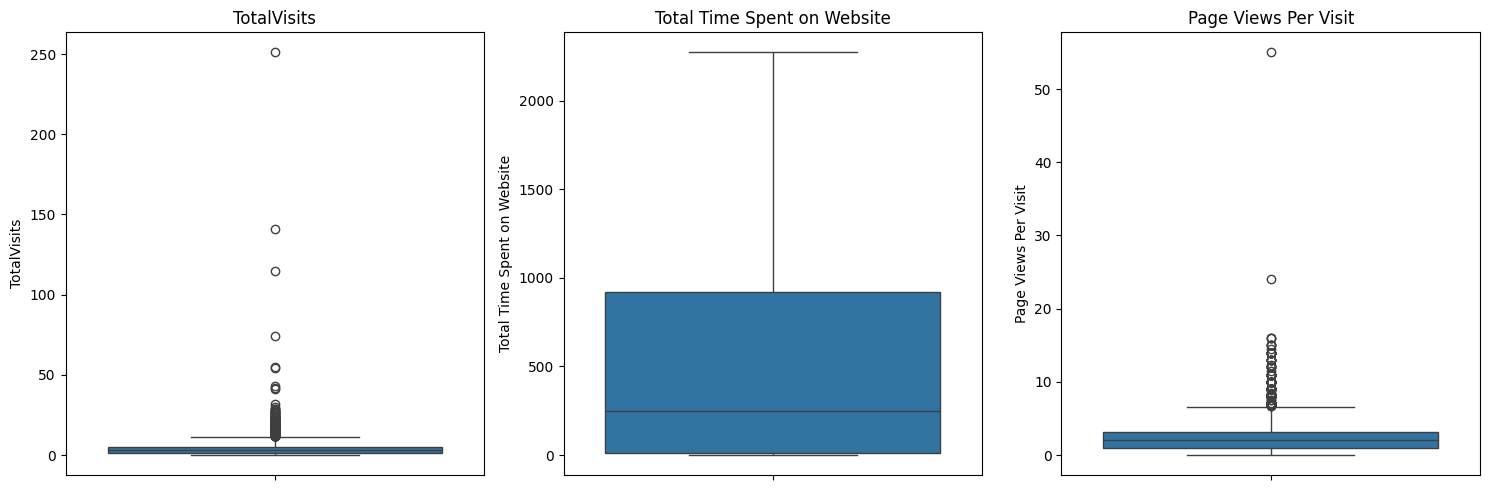

In [16]:
# check the shape of the DataFrame to see how many rows and columns are present after cleaning

num_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

# 3 plots ek sath dekhne ke liye
plt.figure(figsize=(15, 5))

for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=Lead_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [17]:
# Capping outliers in the specified columns to reduce their impact on the analysis

cols_to_cap = ['TotalVisits', 'Page Views Per Visit']

for col in cols_to_cap:
    # limits ko calculate karne ke liye 1st aur 99th percentile ka use karte hain
    lower_limit = Lead_df[col].quantile(0.01)
    upper_limit = Lead_df[col].quantile(0.99)
    
    # clip method ka use karke outliers ko cap karte hain
    Lead_df[col] = Lead_df[col].clip(lower=lower_limit, upper=upper_limit)

print("Outliers Successfully Capped!")

Outliers Successfully Capped!


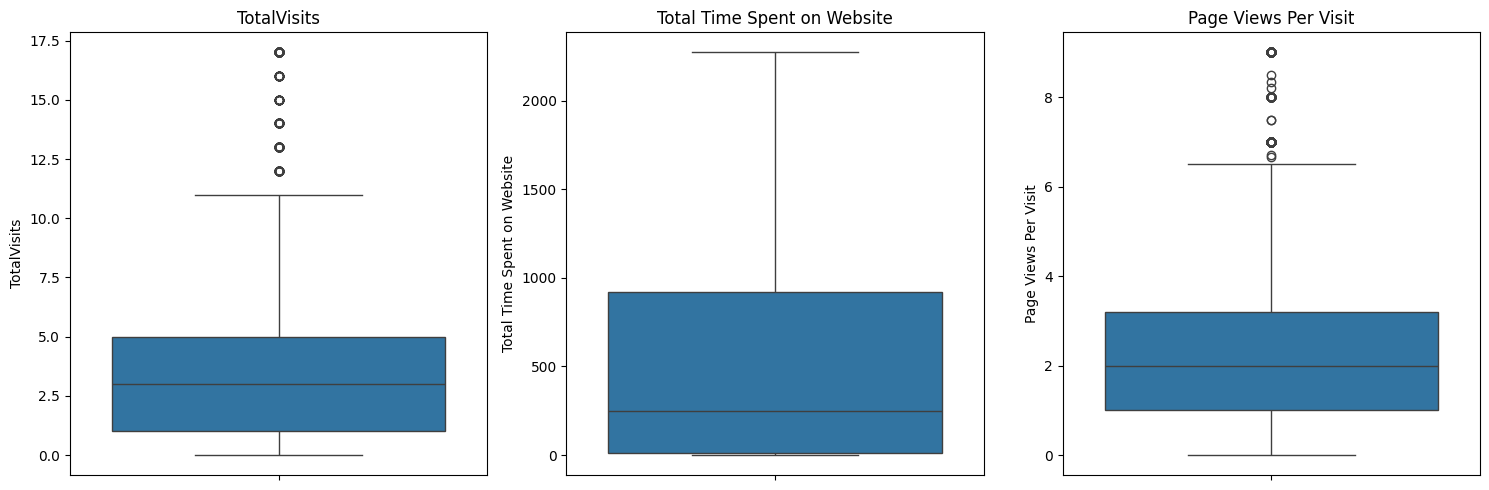

In [18]:
# check the shape of the DataFrame to see how many rows and columns are present after cleaning

num_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

# 3 To see the distribution of the specified numerical columns after capping outliers, we can create boxplots for each column. This will help visualize the data and confirm that the outliers have been effectively capped.


plt.figure(figsize=(15, 5))

for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=Lead_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

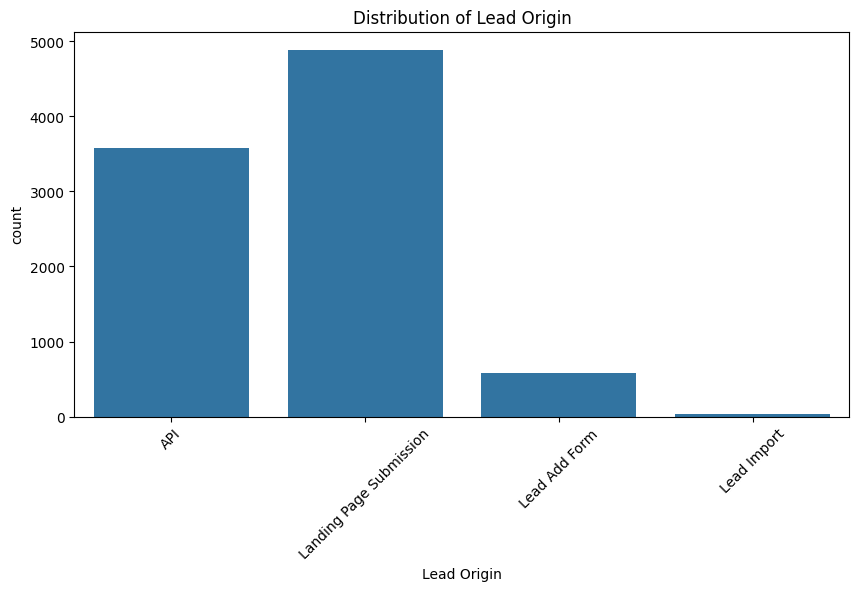

In [19]:


# plotting the distribution of 'Lead Origin' to visualize how leads are distributed across different origins

plt.figure(figsize=(10, 5))
if 'Lead Origin' not in Lead_df.columns:
    Lead_df_plot = pd.read_csv("Leads.csv")
    Lead_df_plot['Lead Origin'] = Lead_df_plot['Lead Origin'].astype(str).str.strip()
else:
    Lead_df_plot = Lead_df

sns.countplot(x='Lead Origin', data=Lead_df_plot)
plt.title('Distribution of Lead Origin')
plt.xticks(rotation=45)
plt.show()

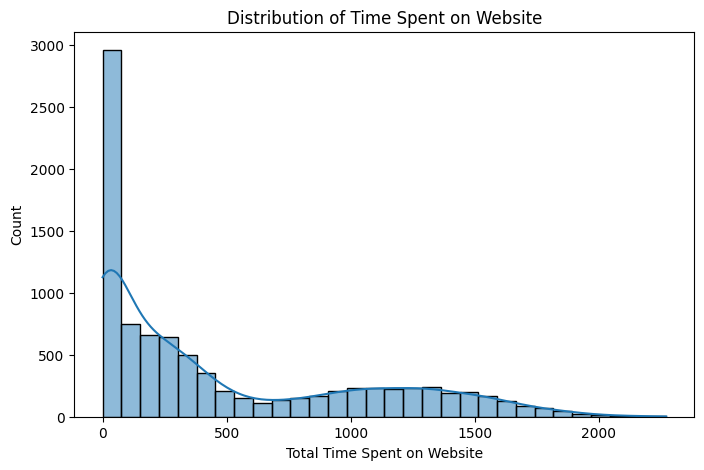

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(Lead_df['Total Time Spent on Website'], bins=30, kde=True)
plt.title('Distribution of Time Spent on Website')
plt.show()

<Figure size 1500x600 with 0 Axes>

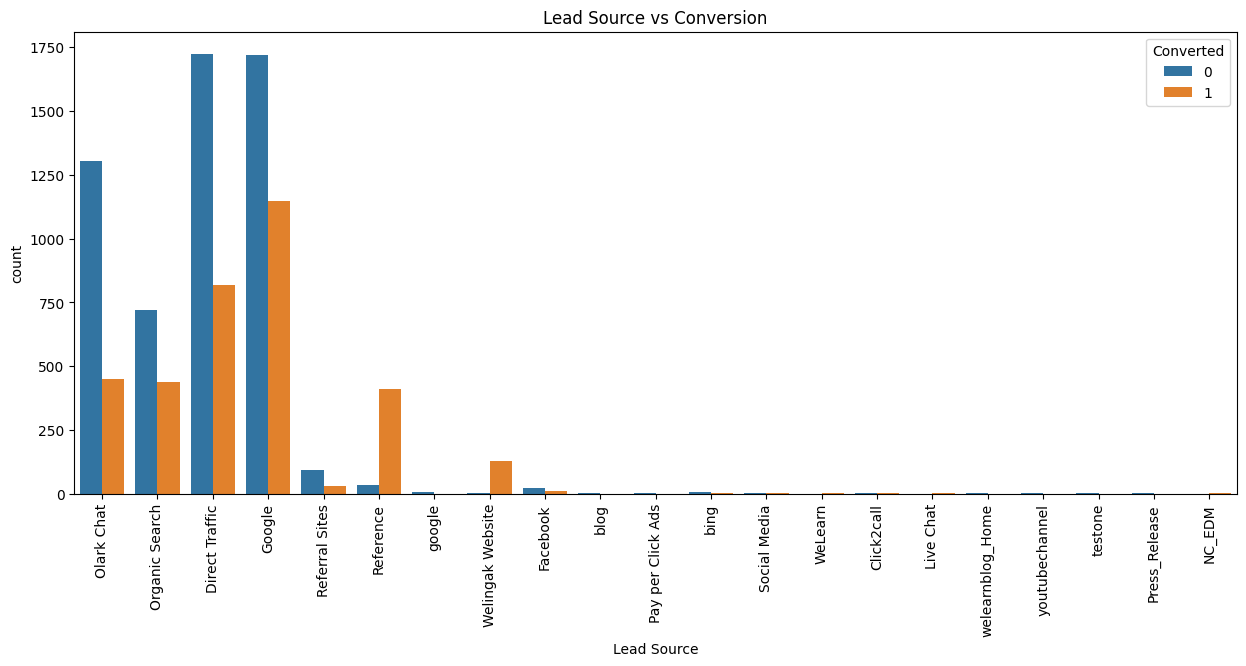

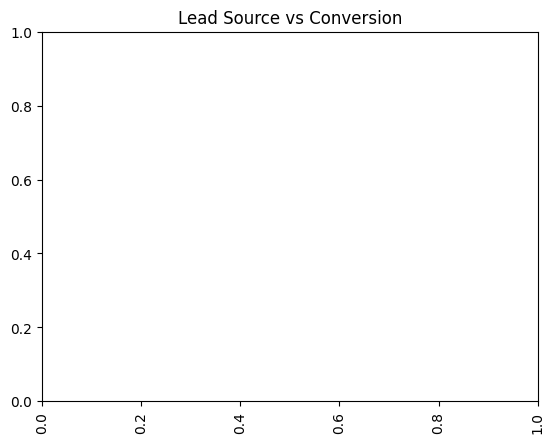

In [21]:
plt.figure(figsize=(15, 6))
# conversion rate by lead source using hue='Converted' to visualize how many leads converted and how many did not from each source
plt.figure(figsize=(15, 6))

if 'Lead Source' not in Lead_df.columns:
    Lead_df_plot = pd.read_csv("Leads.csv")
    Lead_df_plot['Lead Source'] = Lead_df_plot['Lead Source'].astype(str).str.strip()
    Lead_df_plot = Lead_df_plot.dropna(subset=['TotalVisits', 'Page Views Per Visit', 'Last Activity', 'Lead Source'])
    sns.countplot(x='Lead Source', hue='Converted', data=Lead_df_plot)
else:
    sns.countplot(x='Lead Source', hue='Converted', data=Lead_df)

plt.title('Lead Source vs Conversion')
plt.xticks(rotation=90)
plt.show()
plt.title('Lead Source vs Conversion')
plt.xticks(rotation=90)
plt.show()

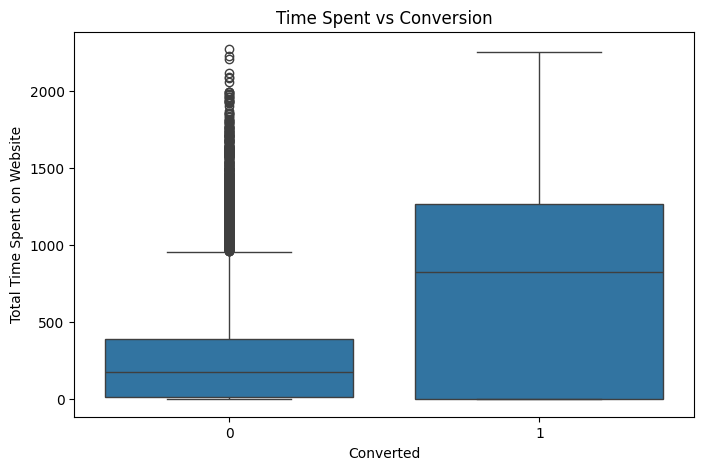

In [22]:
#plotting a boxplot to visualize the relationship between 'Total Time Spent on Website' and 'Converted' status of leads. This will help us understand if there is any correlation between the time spent on the website and the likelihood of conversion.

plt.figure(figsize=(8, 5))
sns.boxplot(x='Converted', y='Total Time Spent on Website', data=Lead_df)
plt.title('Time Spent vs Conversion')
plt.show()

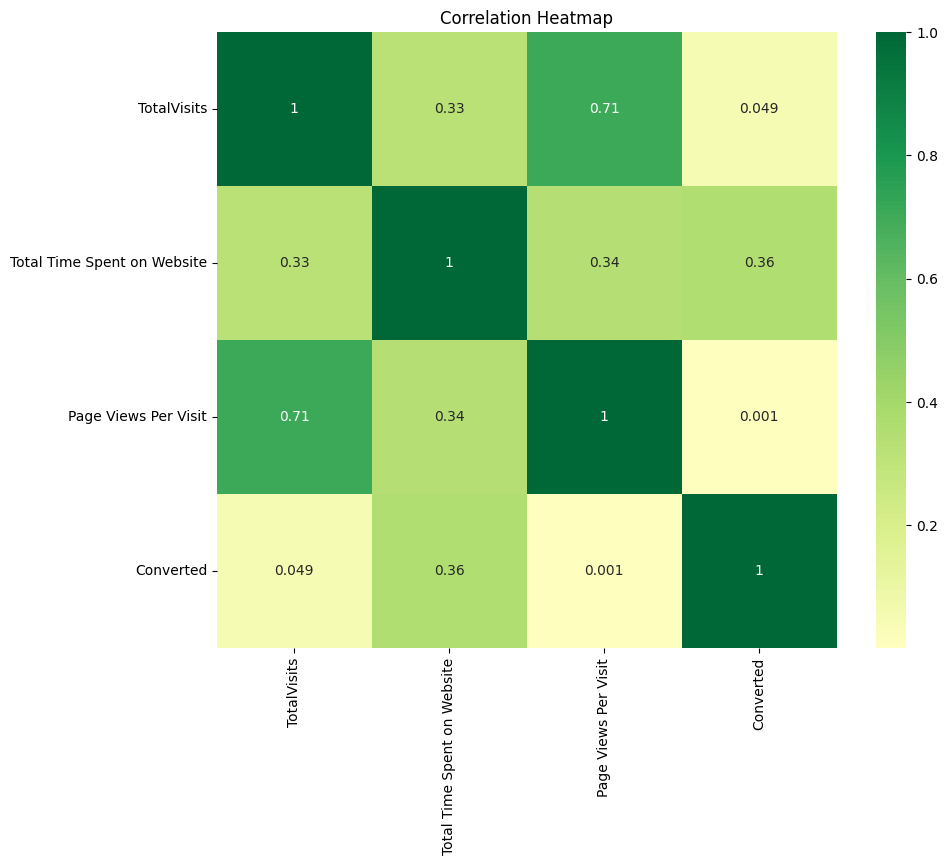

In [23]:
# plotting a heatmap to visualize the correlation between numerical features in the dataset. This will help us understand how different features are related to each other and identify any potential multicollinearity issues.


plt.figure(figsize=(10, 8))
# only calculate correlation for numerical columns
num_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Converted']

# plotting the heatmap to visualize the correlation matrix of the specified numerical columns. The heatmap will display the correlation coefficients, with colors indicating the strength and direction of the correlations.
sns.heatmap(Lead_df[num_cols].corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [24]:

# Check the first few rows of the DataFrame
Lead_df.head()

,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,...,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,...,No,No,Interested in other courses,No,No,NaN,Not Specified,No,No,Modified
1,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,...,No,No,Ringing,No,No,NaN,Not Specified,No,No,Email Opened
2,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,...,No,No,Will revert after reading the email,No,No,Potential Lead,Mumbai,No,Yes,Email Opened
3,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,...,No,No,Ringing,No,No,NaN,Mumbai,No,No,Modified
4,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,...,No,No,Will revert after reading the email,No,No,NaN,Mumbai,No,No,Modified


In [25]:
# Check the summary statistics of the DataFrame

Lead_df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,9074.000000,9074.000000,9074.000000,9074.000000,9074.000000
mean,617032.619352,0.378554,3.343178,482.887481,2.341241
std,23348.029512,0.485053,3.252302,545.256560,1.984635
min,579533.000000,0.000000,0.000000,0.000000,0.000000
25%,596406.000000,0.000000,1.000000,11.000000,1.000000
50%,615278.500000,0.000000,3.000000,246.000000,2.000000
75%,637176.500000,1.000000,5.000000,922.750000,3.200000
max,660737.000000,1.000000,17.000000,2272.000000,9.000000


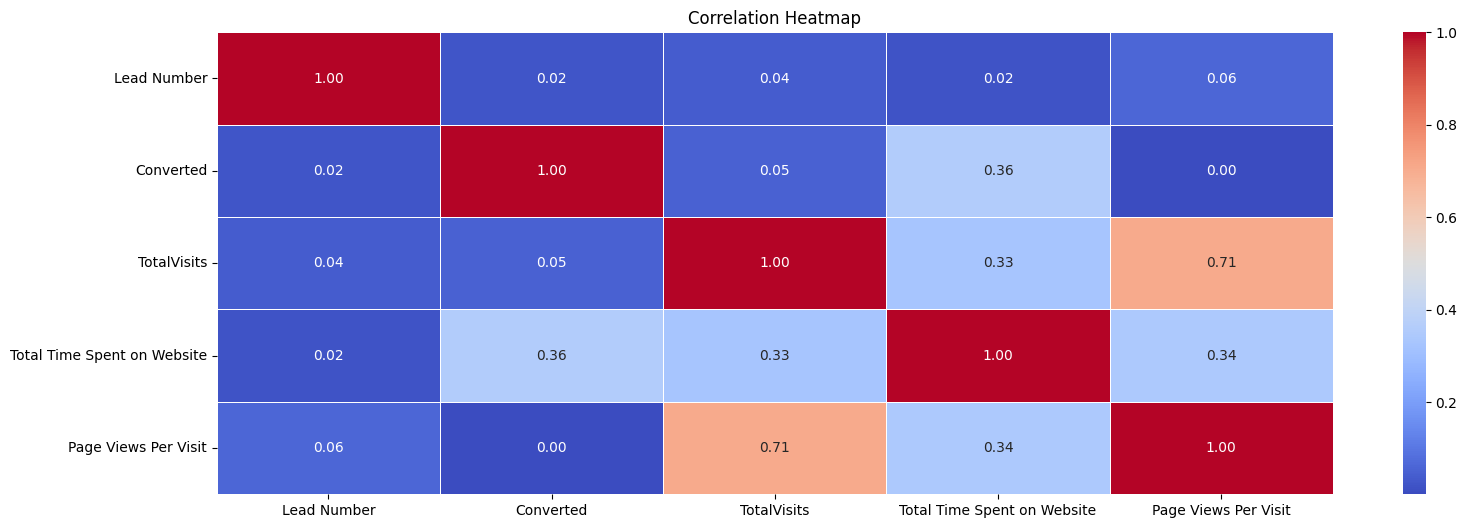

In [26]:

plt.figure(figsize=(18,6))

#selecting only the numerical columns from the dataset to calculate the correlation matrix


numeric_cols=Lead_df.select_dtypes(include=['int64', 'float64'])

#creating a heatmap to visualize the correlation matrix of the numerical features in the dataset

sns.heatmap(numeric_cols.corr(),annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [27]:
Lead_df.head()

,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,...,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,...,No,No,Interested in other courses,No,No,NaN,Not Specified,No,No,Modified
1,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,...,No,No,Ringing,No,No,NaN,Not Specified,No,No,Email Opened
2,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,...,No,No,Will revert after reading the email,No,No,Potential Lead,Mumbai,No,Yes,Email Opened
3,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,...,No,No,Ringing,No,No,NaN,Mumbai,No,No,Modified
4,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,...,No,No,Will revert after reading the email,No,No,NaN,Mumbai,No,No,Modified


In [28]:
## 26. Data Preprocessing


Lead_df['Do Not Email']=Lead_df['Do Not Email'].astype('category').cat.codes
Lead_df['Do Not Call']=Lead_df['Do Not Call'].astype('category').cat.codes
Lead_df['Last Activity']=Lead_df['Last Activity'].astype('category').cat.codes
Lead_df['Through Recommendations']=Lead_df['Through Recommendations'].astype('category').cat.codes
Lead_df['Receive More Updates About Our Courses']=Lead_df['Receive More Updates About Our Courses'].astype('category').cat.codes
Lead_df['Update me on Supply Chain Content']=Lead_df['Update me on Supply Chain Content'].astype('category').cat.codes
Lead_df['Get updates on DM Content']=Lead_df['Get updates on DM Content'].astype('category').cat.codes
Lead_df['I agree to pay the amount through cheque']=Lead_df['I agree to pay the amount through cheque'].astype('category').cat.codes
Lead_df['A free copy of Mastering The Interview']=Lead_df['A free copy of Mastering The Interview'].astype('category').cat.codes
Lead_df['Last Notable Activity']=Lead_df['Last Notable Activity'].astype('category').cat.codes
Lead_df['Lead Profile']=Lead_df['Lead Profile'].astype('category').cat.codes



In [29]:
# for the columns with multiple categories, we will create dummy variables to convert them into numerical format for modeling. This is essential for machine learning algorithms that require numerical input.
dummy_columns = ['Lead Origin', 'Lead Source', 'Last Activity', 'Tags', 
                 'Last Notable Activity', 'Lead Profile', 'City', 'Country']

# for them make dummy variables (Drop first=True is necessary to avoid multicollinearity)
Lead_df = pd.get_dummies(Lead_df, columns=dummy_columns, drop_first=True)

In [30]:
# 1.select only the text columns that are still present in the DataFrame after creating dummy variables
text_columns = Lead_df.select_dtypes(include=['object', 'category']).columns
print("Bache hue text columns jo error de rahe the:", list(text_columns))

# 2. change them all to dummy variables in one go
Lead_df = pd.get_dummies(Lead_df, columns=text_columns, drop_first=True)

# 3. new dummy columns usually come in True/False format.
# change them to 1/0 (Float) so that StandardScaler can process them easily
Lead_df = Lead_df.astype(float)

Bache hue text columns jo error de rahe the: ['Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement']


In [31]:


# 1. seperate the target variable
X = Lead_df.drop(['Converted'], axis=1)
y = Lead_df['Converted']

# 2. train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

# 3. make an object of StandardScaler
scaler = StandardScaler()

# 4. Sselect only those columns which need to be scaled
num_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

# 5. on training data, fit and transform
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# 6. on test data, only transform (do not fit again)
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Data successfully split aur scale ho gaya hai! Model building ke liye ready.")

Data successfully split aur scale ho gaya hai! Model building ke liye ready.


In [32]:


# ---------------------------------------------------------
# 1. RFE (Recursive Feature Elimination) - select top 15 columns
# ---------------------------------------------------------
logreg = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=logreg, n_features_to_select=15)
rfe = rfe.fit(X_train, y_train)

# list of RFE selected columns
rfe_cols = X_train.columns[rfe.support_]
print("RFE selected 15 columns:\n", list(rfe_cols))
print("\n" + "="*60 + "\n")

# ---------------------------------------------------------
# 2. Statsmodels GLM (to check P-Values)
# ---------------------------------------------------------
X_train_rfe = X_train[rfe_cols]
X_train_sm = sm.add_constant(X_train_rfe) # Constant add karna zaroori hai

logm = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial())
res = logm.fit()
print(res.summary())
print("\n" + "="*60 + "\n")

# ---------------------------------------------------------
# 3. VIF Calculation (check for Multicollinearity )
# ---------------------------------------------------------
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_rfe.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_rfe.values, i) for i in range(X_train_rfe.shape[1])]
vif_data['VIF'] = round(vif_data['VIF'], 2)
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("VIF Data:\n", vif_data)

RFE selected 15 columns:
 ['Do Not Email', 'Lead Source_Welingak Website', 'Last Activity_9', 'Tags_Busy', 'Tags_Closed by Horizzon', 'Tags_Lost to EINS', 'Tags_Not Specified', 'Tags_Ringing', 'Tags_Will revert after reading the email', 'Tags_invalid number', 'Tags_switched off', 'Tags_wrong number given', 'Last Notable Activity_12', 'Lead Profile_4', 'What matters most to you in choosing a course_Not Specified']


                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 6351
Model:                            GLM   Df Residuals:                     6335
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1191.4
Date:                Mon, 22 Jun 2026   Deviance:                       2382.9
Time:                       

In [33]:
from sklearn import metrics



# 1. update the old X_train_sm in memory (so that new columns reflect)
X_train_rfe = X_train[rfe_cols] 
X_train_sm = sm.add_constant(X_train_rfe)

# 2. in final model se probabilities predict karein
y_train_pred = res.predict(X_train_sm)

# 3. origional aur Predicted probabilities ki ek table banayein
y_train_pred_final = pd.DataFrame({'Actual_Converted': y_train.values, 'Convert_Prob': y_train_pred})

# 4. make a new column 'Predicted' based on a threshold of 0.5
y_train_pred_final['Predicted'] = y_train_pred_final['Convert_Prob'].map(lambda x: 1 if x > 0.5 else 0)

# 5. print the confusion matrix to see how many predictions were correct and how many were incorrect
confusion = metrics.confusion_matrix(y_train_pred_final['Actual_Converted'], y_train_pred_final['Predicted'])
print("Confusion Matrix:\n", confusion)

# 6. print the accuracy and sensitivity (recall) of the model
# 1. update the old X_train_sm in memory (so that new columns reflect)
X_train_rfe = X_train[rfe_cols] 
X_train_sm = sm.add_constant(X_train_rfe)

# 2. in final model se probabilities predict karein
y_train_pred = res.predict(X_train_sm)

# 3. origional aur Predicted probabilities ki ek table banayein
y_train_pred_final = pd.DataFrame({'Actual_Converted': y_train.values, 'Convert_Prob': y_train_pred})

# 4. make a new column 'Predicted' based on a threshold of 0.5
y_train_pred_final['Predicted'] = y_train_pred_final['Convert_Prob'].map(lambda x: 1 if x > 0.5 else 0)

# 5. print the confusion matrix to see how many predictions were correct and how many were incorrect
confusion = metrics.confusion_matrix(y_train_pred_final['Actual_Converted'], y_train_pred_final['Predicted'])
print("Confusion Matrix:\n", confusion)

# 6. print the accuracy and sensitivity (recall) of the model
accuracy = metrics.accuracy_score(y_train_pred_final['Actual_Converted'], y_train_pred_final['Predicted'])

# from the confusion matrix, extract True Positives (TP) and False Negatives (FN)
TP = confusion[1,1] # True Positives
FN = confusion[1,0] # False Negatives

sensitivity = TP / float(TP+FN)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print(f"Sensitivity (Recall): {sensitivity * 100:.2f}%")

# from the confusion matrix, extract True Positives (TP) and False Negatives (FN)
TP = confusion[1,1] # True Positives
FN = confusion[1,0] # False Negatives

sensitivity = TP / float(TP+FN)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print(f"Sensitivity (Recall): {sensitivity * 100:.2f}%")

Confusion Matrix:
 [[3694  211]
 [ 205 2241]]
Confusion Matrix:
 [[3694  211]
 [ 205 2241]]

Model Accuracy: 93.45%
Sensitivity (Recall): 91.62%

Model Accuracy: 93.45%
Sensitivity (Recall): 91.62%


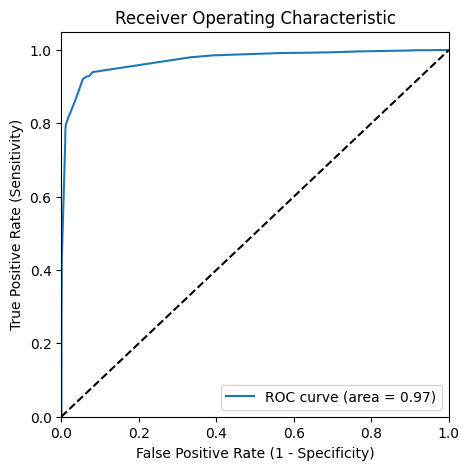

In [ ]:
#plotting the ROC curve to visualize the performance of the model across different thresholds

def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    return None

# roc curve plot for the training data to visualize the model's performance on the training set
draw_roc(y_train_pred_final['Actual_Converted'], y_train_pred_final['Convert_Prob'])

In [35]:
# 1. Take those 15 columns from the test data that were selected by RFE on the training data
X_test_rfe = X_test[rfe_cols]

# 2. add constant for statsmodels
X_test_sm = sm.add_constant(X_test_rfe)

# 3. predict probabilities on the test data using the final model
y_test_pred = res.predict(X_test_sm)

# 4. make a table of actual and predicted probabilities
y_test_pred_final = pd.DataFrame({'Actual_Converted': y_test.values, 'Convert_Prob': y_test_pred})

# 5. bifurcate the predicted probabilities into 0 or 1 based on a threshold of 0.5
y_test_pred_final['Predicted'] = y_test_pred_final['Convert_Prob'].map(lambda x: 1 if x > 0.5 else 0)

# 6. print the confusion matrix to see how many predictions were correct and how many were incorrect
confusion_test = metrics.confusion_matrix(y_test_pred_final['Actual_Converted'], y_test_pred_final['Predicted'])
print("Test Data Confusion Matrix:\n", confusion_test)

# 7. print the accuracy and sensitivity (recall) of the model
accuracy_test = metrics.accuracy_score(y_test_pred_final['Actual_Converted'], y_test_pred_final['Predicted'])

# take True Positives (TP) and False Negatives (FN) from the confusion matrix
TP_test = confusion_test[1,1] 
FN_test = confusion_test[1,0] 

sensitivity_test = TP_test / float(TP_test+FN_test)

print(f"\nTest Model Accuracy: {accuracy_test * 100:.2f}%")
print(f"Test Sensitivity (Recall): {sensitivity_test * 100:.2f}%")

Test Data Confusion Matrix:
 [[1618  116]
 [  97  892]]

Test Model Accuracy: 92.18%
Test Sensitivity (Recall): 90.19%


In [ ]:
import pandas as pd

# 1. took the model parameters (coefficients) and put them into a DataFrame for easier analysis and visualization
params_df = pd.DataFrame({'Variable': res.params.index, 'Coefficient': res.params.values})

# 2. no for 'const' (intercept) because it is not a feature
params_df = params_df[params_df['Variable'] != 'const']

# 3. short the DataFrame by 'Coefficient' in descending order to find the top 3 variables that have a positive impact on conversion probability
top_3_positive = params_df.sort_values(by='Coefficient', ascending=False).head(3)

print("Top 3 Variables Conversion Probability increase:\n")
print(top_3_positive)

Top 3 Variables jo Conversion Probability badhate hain:

                                   Variable  Coefficient
6                         Tags_Lost to EINS     9.094456
5                   Tags_Closed by Horizzon     8.115952
9  Tags_Will revert after reading the email     6.511964


In [ ]:
from sklearn.metrics import classification_report

# 1. classification report for the training data to evaluate the model's performance on the training set
print("📊 Classification Report - TRAIN Data:\n")
print(classification_report(y_train_pred_final['Actual_Converted'], y_train_pred_final['Predicted']))

print("\n" + "="*60 + "\n")

# 2. classification report for the test data to evaluate the model's performance on the test set
print("📊 Classification Report - TEST Data:\n")
print(classification_report(y_test_pred_final['Actual_Converted'], y_test_pred_final['Predicted']))

📊 Classification Report - TRAIN Data:

              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95      3905
         1.0       0.91      0.92      0.92      2446

    accuracy                           0.93      6351
   macro avg       0.93      0.93      0.93      6351
weighted avg       0.93      0.93      0.93      6351



📊 Classification Report - TEST Data:

              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94      1734
         1.0       0.88      0.90      0.89       989

    accuracy                           0.92      2723
   macro avg       0.91      0.92      0.92      2723
weighted avg       0.92      0.92      0.92      2723

